# Environment Setup (GPU, Paths, Imports)

In [2]:
import sys
sys.path.insert(0, "/blue/juannanzhou/fahimeh.rahimi/flashzoi1/VEP_DNA")

import os
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))

import pandas as pd
import numpy as np
from pathlib import Path
import genvarloader as gvl

# Local code
import src.genvarloader as GVL
import src.vep_pipeline as vp
import src.utils as utils
import src.clinvar as cv

import warnings
warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow")


CUDA available: True
Current device: 0
Device name: NVIDIA A100-SXM4-80GB


# Prepare GVL Store, Reference Data, Load Variant Table

In [3]:
cd /blue/juannanzhou/fahimeh.rahimi/flashzoi1

/blue/juannanzhou/fahimeh.rahimi/flashzoi1


In [4]:
REFERENCE_BGZ = "/blue/juannanzhou/fahimeh.rahimi/flashzoi/chr22.fa.gz"
PLINK_PGEN    = "/blue/juannanzhou/fahimeh.rahimi/flashzoi/1kGP.chr22.pgen"
BED_WINDOWS   = "/blue/juannanzhou/fahimeh.rahimi/flashzoi1/VEP_DNA/data/UTR/clinvar_utr_snv.bed.gz"
SITE_VCF      = "/blue/juannanzhou/fahimeh.rahimi/flashzoi1/filtered_chr22_snps.vcf"

DS_PATH = Path("/blue/juannanzhou/fahimeh.rahimi/flashzoi1/vep_dna/gvl_chr22")
meta_file = DS_PATH / "metadata.json"

if not meta_file.exists():
    import shutil
    if DS_PATH.exists():
        print(f"⚠️  Found {DS_PATH} but no metadata.json → removing and rebuilding")
        shutil.rmtree(DS_PATH)
    else:
        print(f"▶ Building new GVL store at {DS_PATH}")
    DS_PATH.mkdir(parents=True, exist_ok=True)
    gvl.write(
        path      = str(DS_PATH),
        bed       = gvl.with_length(gvl.read_bedlike(BED_WINDOWS), 2**18),
        variants  = PLINK_PGEN,
        overwrite = True,
    )
    print("✅ GVL store built.")
else:
    print(f"✅ Reusing existing GVL store at {DS_PATH}")

ds = (
    gvl.Dataset.open(str(DS_PATH), reference=REFERENCE_BGZ)
       .with_seqs("haplotypes")
       .with_len(2**18)
)
print("Loaded GVL store with", ds.n_regions, "regions.")

# Load all variants with annotation (assuming ClinVar annotations included)
all_sites = gvl.sites_vcf_to_table(SITE_VCF)
print("All UTR variants loaded:", len(all_sites))
display(all_sites.head())


✅ Reusing existing GVL store at /blue/juannanzhou/fahimeh.rahimi/flashzoi1/vep_dna/gvl_chr22


2025-05-23 11:10:03.911 | INFO     | genvarloader._dataset._impl:open:201 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-05-23 11:10:04.117 | INFO     | genvarloader._dataset._reconstruct:from_path:192 - Loading variant data.
2025-05-23 11:10:04.603 | INFO     | genvarloader._dataset._impl:open:287 - Opened dataset:
GVL store at /blue/juannanzhou/fahimeh.rahimi/flashzoi1/vep_dna/gvl_chr22
Is subset: False
# of regions: 5529
# of samples: 451
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None



Loaded GVL store with 5529 regions.


[E::idx_find_and_load] Could not retrieve index file for '/blue/juannanzhou/fahimeh.rahimi/flashzoi1/filtered_chr22_snps.vcf'
[E::idx_find_and_load] Could not retrieve index file for '/blue/juannanzhou/fahimeh.rahimi/flashzoi1/filtered_chr22_snps.vcf'
[E::idx_find_and_load] Could not retrieve index file for '/blue/juannanzhou/fahimeh.rahimi/flashzoi1/filtered_chr22_snps.vcf'


Reading records: 0 record [00:00, ? record/s]

[W::vcf_parse] Contig '22' is not defined in the header. (Quick workaround: index the file with tabix.)


All UTR variants loaded: 5529


CHROM,POS,REF,ALT
str,i64,str,str
"""22""",17085042,"""T""","""C"""
"""22""",17085050,"""G""","""A"""
"""22""",17085053,"""C""","""T"""
"""22""",17085059,"""C""","""G"""
"""22""",17085065,"""C""","""G"""


In [ ]:
# Running flashzoi using bot

In [6]:
import sys
sys.path.insert(0, "/blue/juannanzhou/fahimeh.rahimi/flashzoi1/VEP_DNA/src")


In [26]:
import polars as pl
import numpy as np
import pandas as pd
from tqdm import tqdm

# Import FlashZoi functions
from flashzoi import score_all_tracks, load_model, load_tokenizer

# 1. Load annotation and select variants
annot_path = "/blue/juannanzhou/fahimeh.rahimi/flashzoi1/data/Filtered_chr22_SNPs.csv"
annot = pl.read_csv(annot_path)
annot = annot.with_columns(pl.col("CHROM").str.replace("^chr", ""))

# Merge with all_sites (assumes all_sites already loaded)
merged = all_sites.join(annot, on=['CHROM', 'POS', 'REF', 'ALT'], how='inner')
benign_variants = merged.filter(pl.col('CLNSIG').str.to_lowercase().str.contains('benign')).head(5)
pathogenic_variants = merged.filter(pl.col('CLNSIG').str.to_lowercase().str.contains('pathogenic')).head(5)
selected_variants = pl.concat([benign_variants, pathogenic_variants]).with_columns([
    pl.col("POS").cast(int)
])
print("Selected variants (should be 10):", selected_variants.shape)
display(selected_variants.select(['CHROM','POS','REF','ALT','CLNSIG']))

# 2. Haplotype extraction function
SEQ_LEN = 196608   # 98,304 bp to each side (centered on variant)

def get_haplotype_sequence(site_ds, variant_idx, sample_idx, ploidy_idx, window=SEQ_LEN):
    sites = site_ds.sites
    chrom = sites[variant_idx, "CHROM"] if "CHROM" in sites.columns else sites[variant_idx, "chrom"]
    pos   = sites[variant_idx, "POS"] if "POS" in sites.columns else sites[variant_idx, "chromStart"] + 1
    ref   = sites[variant_idx, "REF"]
    alt   = sites[variant_idx, "ALT"]

    half_win = window // 2
    seq_start = pos - half_win
    seq_end = pos + half_win

    pad_left = 0
    if seq_start < 0:
        pad_left = -seq_start
        seq_start = 0

    # Fetch sequence from reference
    ref_seq = site_ds.dataset._seqs.reference.fetch(str(chrom), int(seq_start), int(seq_end))
    seq_list = [b.decode() if isinstance(b, (bytes, np.bytes_)) else b for b in ref_seq]

    # Pad left if needed
    if pad_left > 0:
        seq_list = ['N'] * pad_left + seq_list

    # Pad right if needed
    if len(seq_list) < window:
        seq_list += ['N'] * (window - len(seq_list))

    rel_pos = half_win
    gt = site_ds.dataset._seqs.genotypes[variant_idx, sample_idx, ploidy_idx]
    if isinstance(gt, (np.ndarray, list)):
        gt_scalar = int(gt[0]) if len(gt) > 0 else 0
    else:
        gt_scalar = int(gt)

    if gt_scalar == 1 and 0 <= rel_pos < window:
        seq_list[rel_pos] = alt
    return "".join(seq_list)

# 3. Prepare site_ds for selected variants
if not isinstance(selected_variants, pl.DataFrame):
    selected_variants = pl.from_pandas(selected_variants)
site_ds = gvl.DatasetWithSites(ds, selected_variants)
import src.genvarloader as GVL
GVL.add_site_name(site_ds)
print("Prepared site_ds for selected 10 variants.")

# 4. Scoring Loop
model = load_model()
tokenizer = load_tokenizer()

n_variants = selected_variants.height
n_samples = site_ds.dataset._seqs.genotypes.shape[1]
n_ploidy = site_ds.dataset._seqs.genotypes.shape[2]

results = []

for variant_idx in tqdm(range(n_variants), desc="Variants"):
    for sample_idx in range(n_samples):
        for ploidy_idx in range(n_ploidy):
            ref_seq = get_haplotype_sequence(site_ds, variant_idx, sample_idx, ploidy_idx, window=SEQ_LEN)
            alt_seq = list(ref_seq)
            rel_pos = SEQ_LEN // 2
            if 0 <= rel_pos < len(alt_seq):
                alt_seq[rel_pos] = selected_variants[variant_idx, "ALT"]
            alt_seq = "".join(alt_seq)

            if len(ref_seq) != SEQ_LEN or len(alt_seq) != SEQ_LEN:
                print(f"BAD LENGTH at var={variant_idx}, sample={sample_idx}, ploidy={ploidy_idx}: ref={len(ref_seq)}, alt={len(alt_seq)}")
                continue

            # Score and convert tensors to numpy
            score_ref = score_all_tracks(ref_seq, model=model, tokenizer=tokenizer)
            score_alt = score_all_tracks(alt_seq, model=model, tokenizer=tokenizer)
            if hasattr(score_ref, "cpu"):
                score_ref = score_ref.cpu().numpy()
            if hasattr(score_alt, "cpu"):
                score_alt = score_alt.cpu().numpy()

            delta = np.mean(np.abs(score_alt - score_ref))
            covr = np.max(np.abs(np.log2((score_alt + 1e-6) / (score_ref + 1e-6))))

            results.append({
                "variant_idx": variant_idx,
                "sample_idx": sample_idx,
                "ploidy_idx": ploidy_idx,
                "CHROM": selected_variants[variant_idx, "CHROM"],
                "POS": selected_variants[variant_idx, "POS"],
                "REF": selected_variants[variant_idx, "REF"],
                "ALT": selected_variants[variant_idx, "ALT"],
                "CLNSIG": selected_variants[variant_idx, "CLNSIG"],
                "delta": float(delta),
                "COVR": float(covr),
            })

results_df = pd.DataFrame(results)
results_df.to_csv("/orange/juannanzhou/ClinVar_UTR_results/flashzoi_10vars_delta_covr.csv", index=False)
print("Saved metrics for all haplotypes/variants.")
display(results_df.head())


Selected variants (should be 10): (10, 21)


CHROM,POS,REF,ALT,CLNSIG
str,i64,str,str,str
"""22""",17085042,"""T""","""C""","""Benign"""
"""22""",17085059,"""C""","""G""","""Benign"""
"""22""",17085084,"""G""","""C""","""Benign"""
"""22""",17085086,"""C""","""G""","""Likely_benign"""
"""22""",17109854,"""T""","""C""","""Benign"""
"""22""",17207277,"""G""","""C""","""Pathogenic/Likely_pathogenic"""
"""22""",17207279,"""G""","""A""","""Likely_pathogenic"""
"""22""",17207287,"""G""","""T""","""Pathogenic"""
"""22""",17209578,"""G""","""A""","""Conflicting_classifications_of…"


Prepared site_ds for selected 10 variants.


Variants:   0%|          | 0/10 [00:00<?, ?it/s]/blue/juannanzhou/fahimeh.rahimi/flashzoi_gvl_env/lib/python3.11/site-packages/borzoi_pytorch/pytorch_borzoi_model.py:282: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Variants: 100%|██████████| 10/10 [1:36:08<00:00, 576.83s/it]


Saved metrics for all haplotypes/variants.


,variant_idx,sample_idx,ploidy_idx,CHROM,POS,REF,ALT,CLNSIG,delta,COVR
0,0,0,0,22,17085042,T,C,Benign,0.001504,0.595417
1,0,0,1,22,17085042,T,C,Benign,0.001504,0.595417
2,0,1,0,22,17085042,T,C,Benign,0.001504,0.595417
3,0,1,1,22,17085042,T,C,Benign,0.001504,0.595417
4,0,2,0,22,17085042,T,C,Benign,0.001504,0.595417


# plot 

/scratch/local/3368775/ipykernel_1347174/2562717418.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="CLNSIG_CLASS", y="delta", data=results_df, inner="box", palette="Set1")


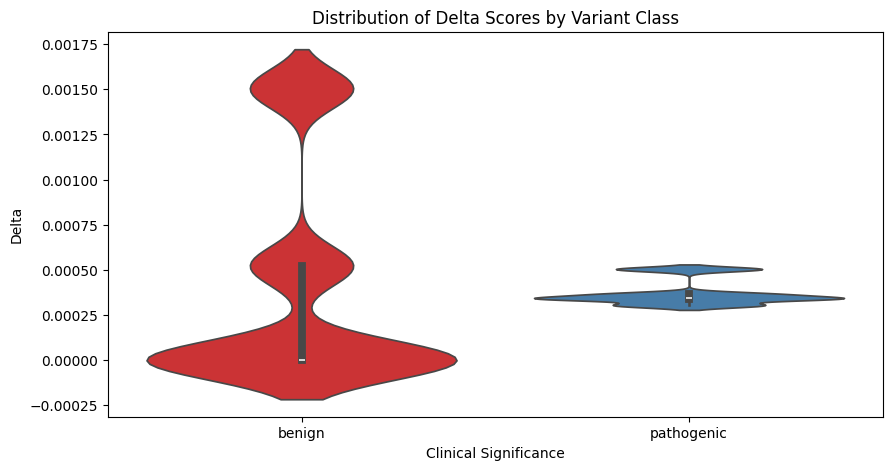

/scratch/local/3368775/ipykernel_1347174/2562717418.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="CLNSIG_CLASS", y="COVR", data=results_df, inner="box", palette="Set2")


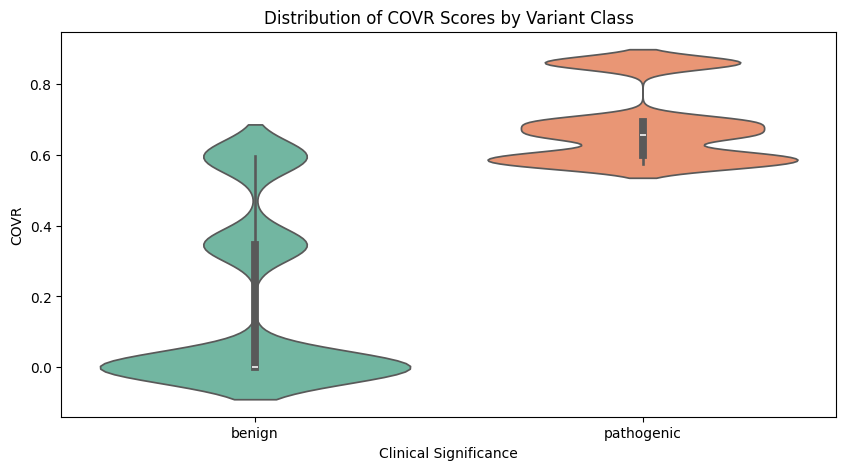

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map to simplified class
def classify_sig(sig):
    s = str(sig).lower()
    if "benign" in s and not "pathogenic" in s:
        return "benign"
    elif "pathogenic" in s:
        return "pathogenic"
    else:
        return "other"

results_df["CLNSIG_CLASS"] = results_df["CLNSIG"].apply(classify_sig)

# Delta plot
plt.figure(figsize=(10, 5))
sns.violinplot(x="CLNSIG_CLASS", y="delta", data=results_df, inner="box", palette="Set1")
plt.title("Distribution of Delta Scores by Variant Class")
plt.xlabel("Clinical Significance")
plt.ylabel("Delta")
plt.show()

# COVR plot
plt.figure(figsize=(10, 5))
sns.violinplot(x="CLNSIG_CLASS", y="COVR", data=results_df, inner="box", palette="Set2")
plt.title("Distribution of COVR Scores by Variant Class")
plt.xlabel("Clinical Significance")
plt.ylabel("COVR")
plt.show()
